# Solutions: matter effects and bi-probability plots

Worked examples that go beyond the tutorial, for **T2K, Hyper-K, NOvA and DUNE**
(the results of the tutorial exercises are in `tutorial_exercises_results.ipynb`):

1. appearance probabilities in vacuum and matter, NO and IO;
2. the matter / vacuum ratio;
3. the $\nu_\mu$ channels vs $L/E$;
4. bi-probability plots (probabilities at the typical energy);
5. bi-event plots (number of selected $e$-like events, from `far_detector_spectra/`);
6. at fixed energy, $\delta_{CP}$ shows up as a different number of counts;
7. absolute vs relative measurement: why antineutrinos are needed to measure $\delta_{CP}$;
8. $P(\nu_e\to\nu_e)$ does not depend on $\delta_{CP}$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from nuosc import NeutrinoOscillator, get_experiment, K_PHASE, predict, load_fd_spectra
from nuosc.plotting import set_style

SET_STYLE = True     # True: nuosc style (latex_style -> SciencePlots -> default); False: keep your own matplotlib settings
c = set_style(SET_STYLE)   # list of colours used in the plots

EXPERIMENTS = ["T2K", "HyperK", "NOvA", "DUNE"]
ORDERINGS = ["NO", "IO"]

def label(a, b, anti=False):
    names = {"e": "e", "mu": r"\mu", "tau": r"\tau"}
    nu = r"\bar\nu" if anti else r"\nu"
    return rf"$P({nu}_{{{names[a]}}}\to{nu}_{{{names[b]}}})$"

plot style: latex_style


## 1. Appearance probability: vacuum vs matter

Solid: matter, dashed: vacuum. The dotted line marks the typical energy of each experiment.
T2K and Hyper-K have the same baseline and beam, so their probabilities are identical.

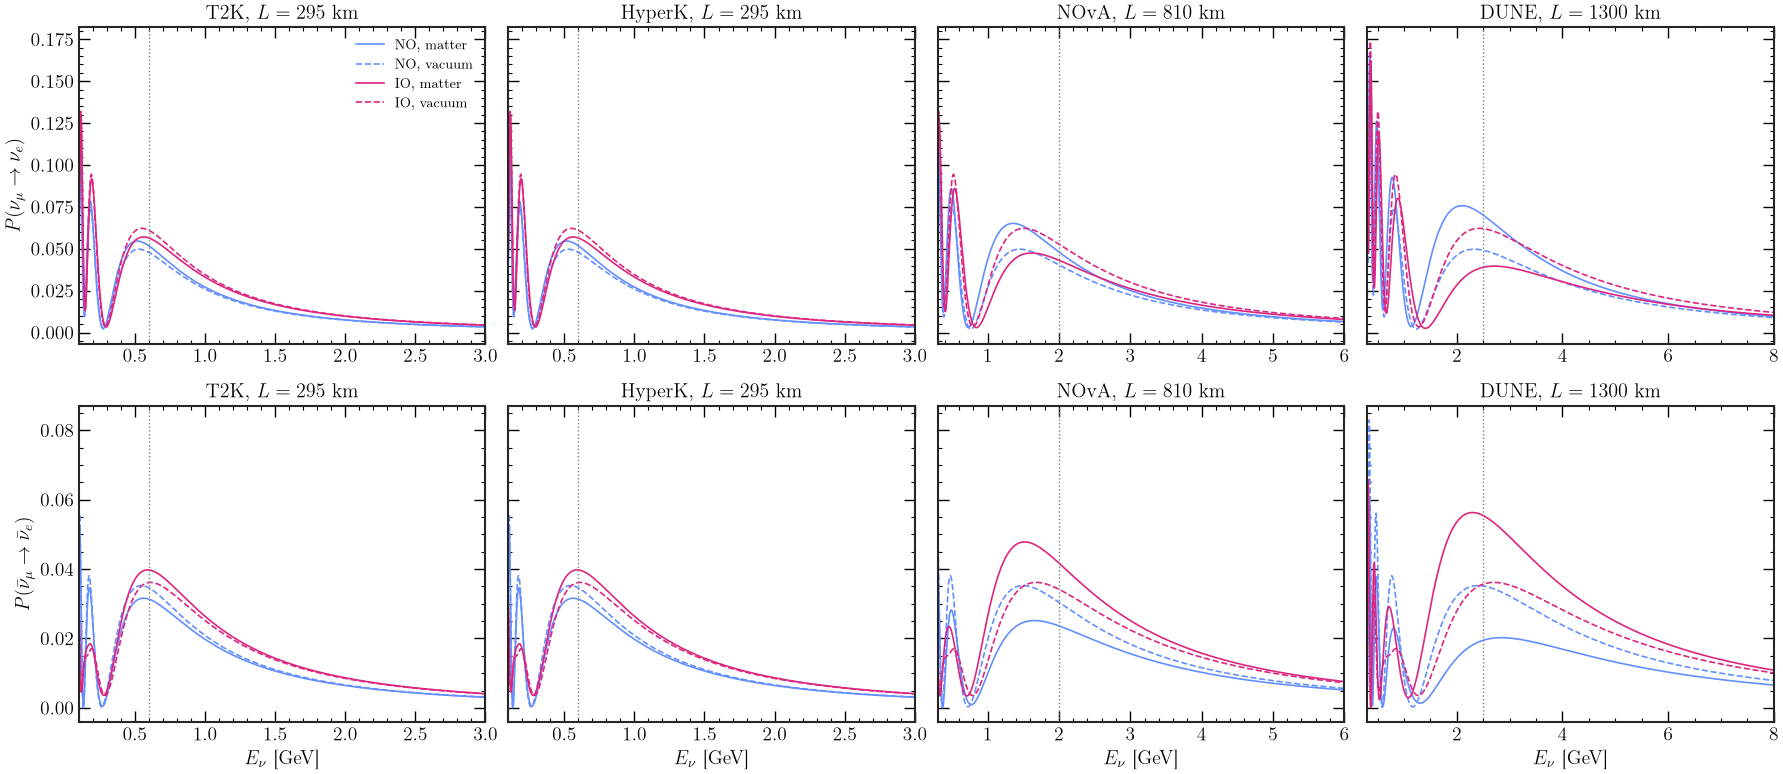

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey="row")
for j, name in enumerate(EXPERIMENTS):
    cfg = get_experiment(name)
    for row, anti in enumerate([False, True]):
        ax = axes[row, j]
        for i, o in enumerate(ORDERINGS):
            osc = NeutrinoOscillator.from_experiment(name, ordering=o, antineutrino=anti)
            ax.plot(osc.energy, osc.matter("mu", "e"), color=c[i], label=f"{o}, matter")
            ax.plot(osc.energy, osc.vacuum("mu", "e"), color=c[i], ls="--", label=f"{o}, vacuum")
        ax.axvline(cfg["E_peak"], color="grey", ls=":", lw=1)
        ax.set_xlim(*cfg["E_range"])
        ax.set_title(rf"{name}, $L = {cfg['baseline']:g}$ km")
        if j == 0:
            ax.set_ylabel(label("mu", "e", anti))
        if row == 1:
            ax.set_xlabel(r"$E_\nu$ [GeV]")
axes[0, 0].legend(fontsize="small")
plt.tight_layout()
plt.show()

## 2. Matter / vacuum ratio

The matter potential grows with $E$ and its effect accumulates with $L$: the longer the baseline,
the larger the effect (DUNE ≫ NOvA ≫ T2K/Hyper-K). For NO, matter **enhances** $\nu_\mu\to\nu_e$ and
**suppresses** $\bar\nu_\mu\to\bar\nu_e$; for IO the opposite.

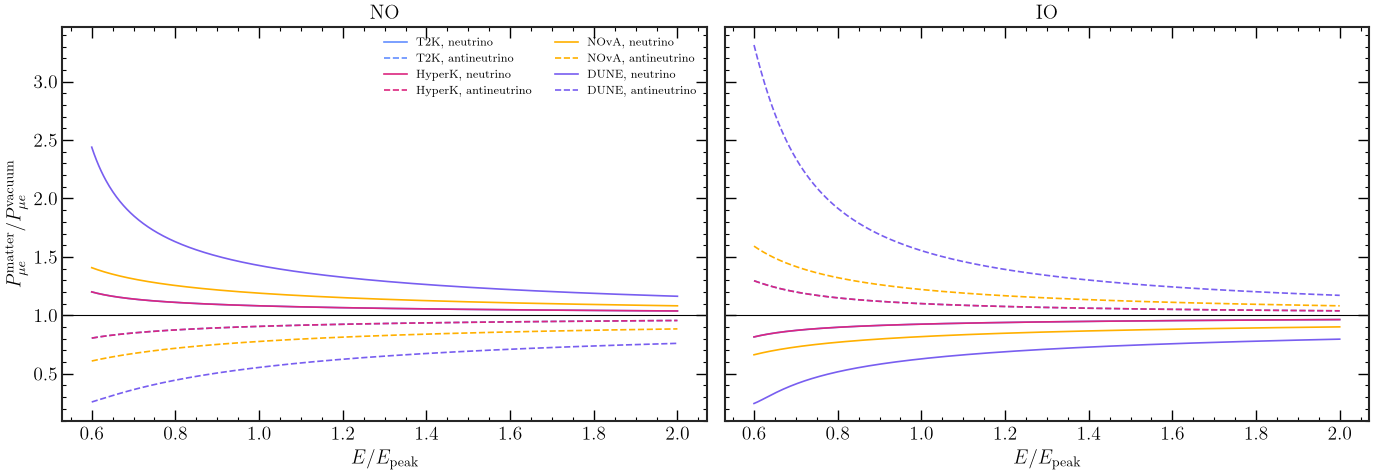

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, o in zip(axes, ORDERINGS):
    for j, name in enumerate(EXPERIMENTS):
        cfg = get_experiment(name)
        for anti, ls in [(False, "-"), (True, "--")]:
            osc = NeutrinoOscillator.from_experiment(name, ordering=o, antineutrino=anti)
            E = np.linspace(0.6 * cfg["E_peak"], 2 * cfg["E_peak"], 500)   # around the 1st maximum
            ax.plot(E / cfg["E_peak"], osc.matter("mu", "e", E) / osc.vacuum("mu", "e", E),
                    color=c[j], ls=ls, label=f"{name}, {'antineutrino' if anti else 'neutrino'}")
    ax.axhline(1, color="k", lw=0.8)
    ax.set_xlabel(r"$E / E_\mathrm{peak}$")
    ax.set_title(o)
axes[0].set_ylabel(r"$P^\mathrm{matter}_{\mu e} / P^\mathrm{vacuum}_{\mu e}$")
axes[0].legend(fontsize="x-small", ncol=2)
plt.tight_layout()
plt.show()

## 3. The $\nu_\mu$ channels vs $L/E$

In vacuum the probabilities depend only on $L/E$, so all experiments lie on the same curve;
matter breaks the scaling (mostly in $\nu_\mu\to\nu_e$). Dotted: atmospheric maxima
$L/E = (2n-1)\pi/(2\cdot1.267\,\Delta m^2_{31})$.

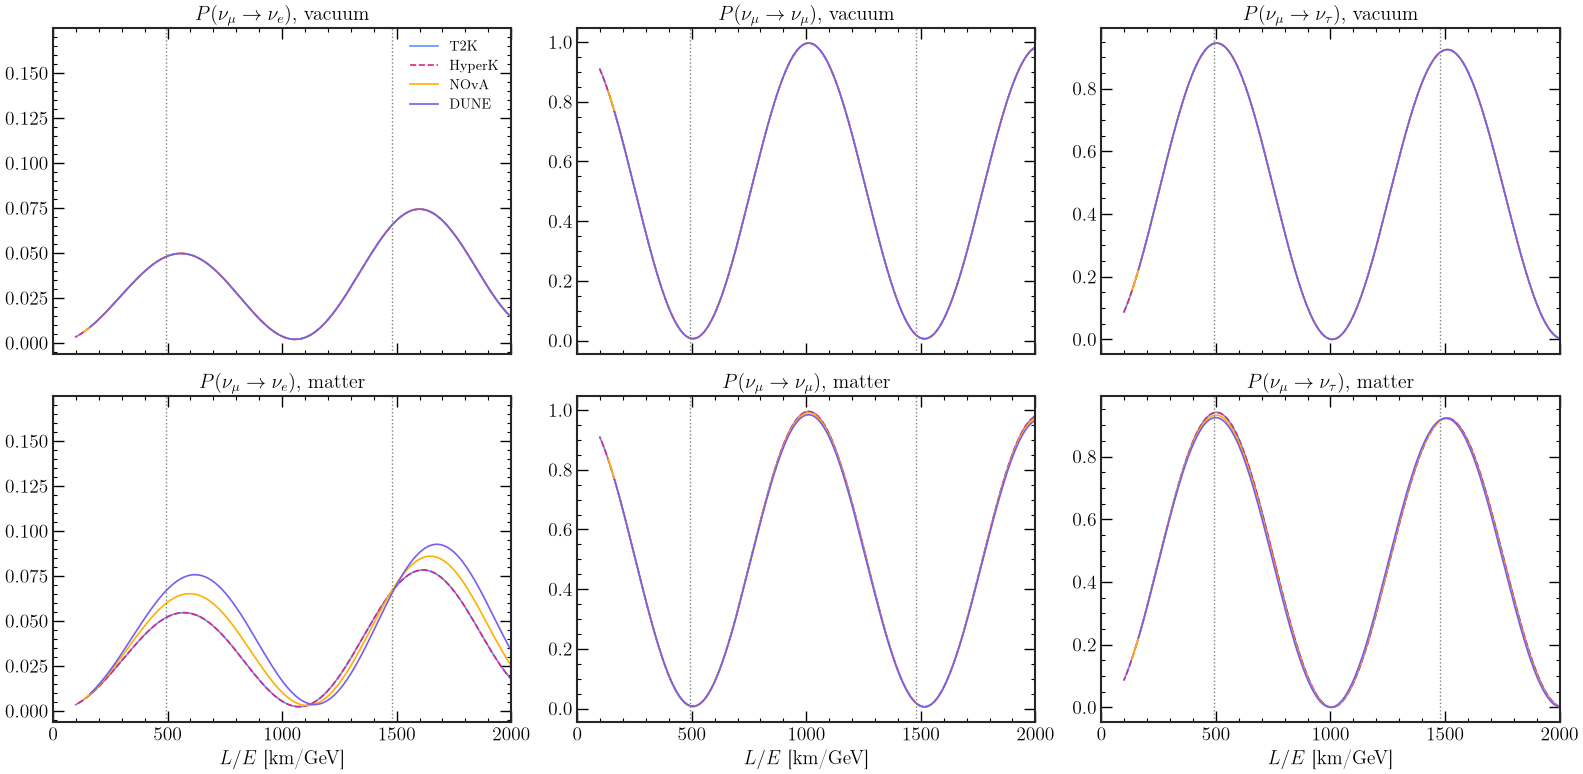

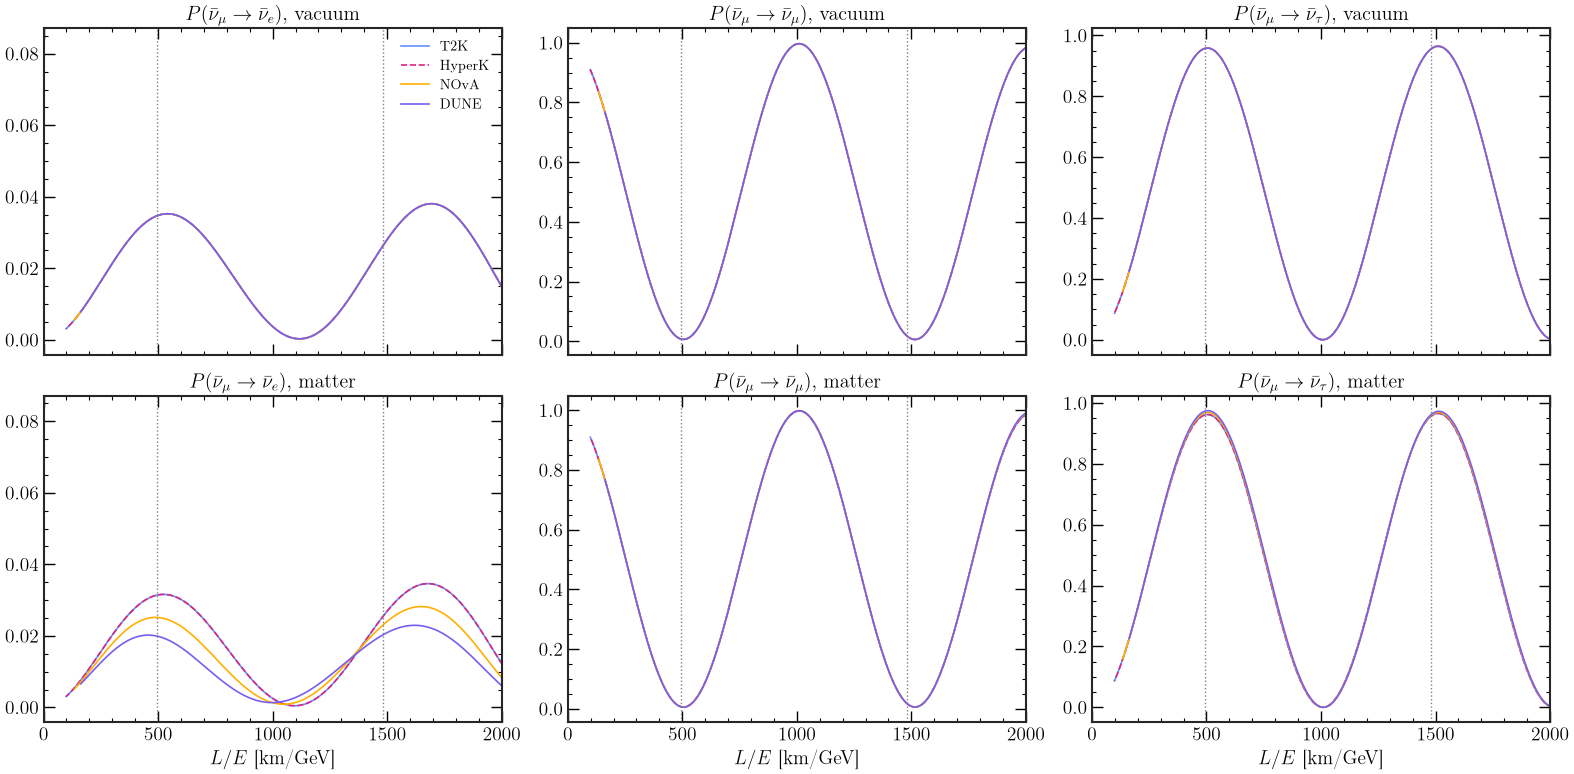

In [ ]:
channels = [("mu", "e"), ("mu", "mu"), ("mu", "tau")]
dm2_31 = NeutrinoOscillator("NO").dm2_31
LE_max = [(2 * n - 1) * np.pi / (2 * K_PHASE * dm2_31) for n in (1, 2)]

for anti in [False, True]:
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey="col")
    for j, name in enumerate(EXPERIMENTS):
        osc = NeutrinoOscillator.from_experiment(name, ordering="NO", antineutrino=anti)
        LE = osc.baseline / osc.energy
        for row, matter in enumerate([False, True]):
            P = osc.probability(matter=matter)
            for col, (a, b) in enumerate(channels):
                axes[row, col].plot(LE, P[1, {"e": 0, "mu": 1, "tau": 2}[b]], color=c[j],
                                    ls="--" if name == "HyperK" else "-", label=name)
    for col, (a, b) in enumerate(channels):
        axes[0, col].set_title(label(a, b, anti) + ", vacuum")
        axes[1, col].set_title(label(a, b, anti) + ", matter")
        axes[1, col].set_xlabel(r"$L/E$ [km/GeV]")
        for ax in axes[:, col]:
            for x in LE_max:
                ax.axvline(x, color="grey", ls=":", lw=1)
    axes[0, 0].set_xlim(0, 2000)
    axes[0, 0].legend(fontsize="small")
    plt.tight_layout()
    plt.show()

## 4. Bi-probability plots

At the typical energy of each experiment, $\delta_{CP}$ goes from 0 to 360° and traces an ellipse in the
$\left(P(\nu_\mu\to\nu_e), P(\bar\nu_\mu\to\bar\nu_e)\right)$ plane. Solid: matter, dashed: vacuum.
Circles: $\delta_{CP}=0$; squares: $\delta_{CP}=90^\circ$.

* In vacuum NO and IO give almost the same ellipse (they differ only because NuFIT prefers different
  $\theta_{23}$ for the two orderings).
* Matter pulls the orderings apart along the diagonal; the separation grows with the baseline.
* Moving *along* an ellipse is the CP-violating effect.

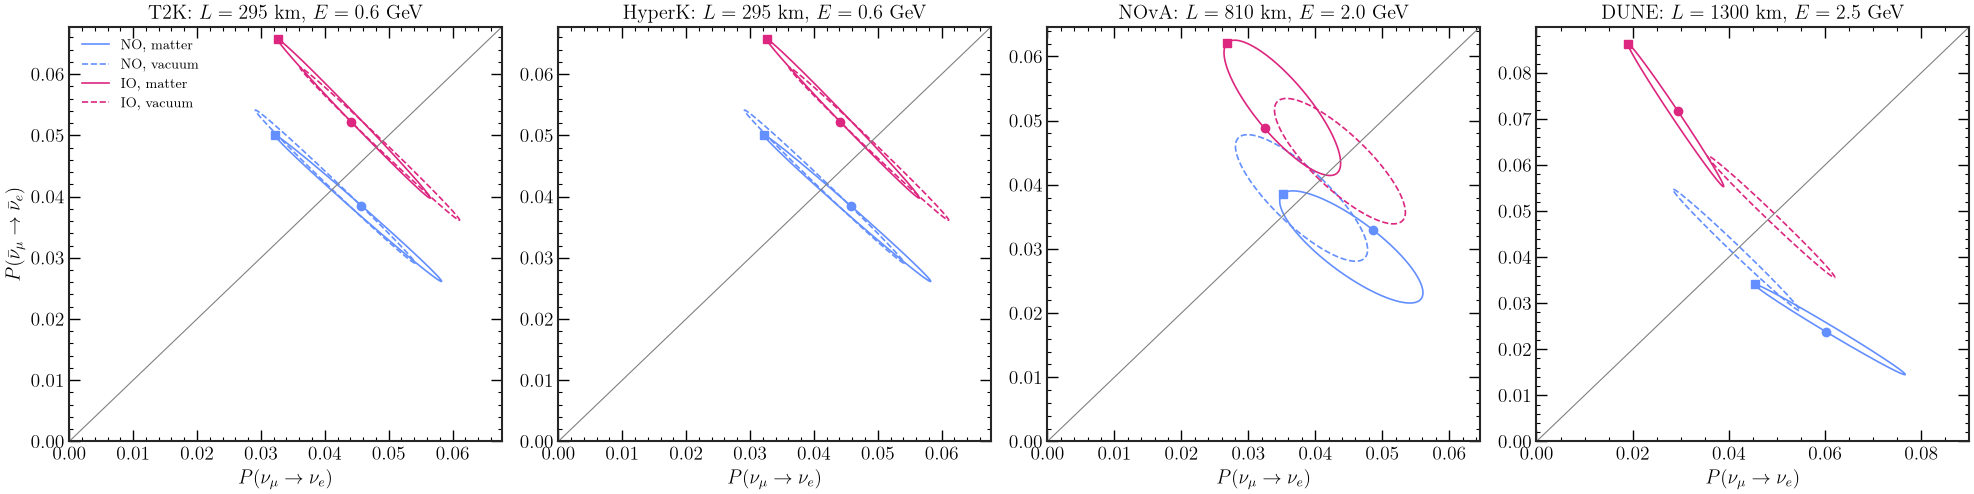

In [ ]:
deltas = np.linspace(0, 360, 361)

def biprob(name, ordering, matter, E):
    nu = NeutrinoOscillator.from_experiment(name, ordering=ordering)
    nub = NeutrinoOscillator.from_experiment(name, ordering=ordering, antineutrino=True)
    p, pb = [], []
    for d in deltas:
        nu.set_params(delta_cp=d); nub.set_params(delta_cp=d)
        p.append(nu.probability("mu", "e", E=E, matter=matter))
        pb.append(nub.probability("mu", "e", E=E, matter=matter))
    return np.array(p), np.array(pb)

fig, axes = plt.subplots(1, 4, figsize=(20, 5.2))
for ax, name in zip(axes, EXPERIMENTS):
    cfg = get_experiment(name)
    for i, o in enumerate(ORDERINGS):
        for matter, ls in [(True, "-"), (False, "--")]:
            p, pb = biprob(name, o, matter, cfg["E_peak"])
            ax.plot(p, pb, color=c[i], ls=ls, label=f"{o}, {'matter' if matter else 'vacuum'}")
            if matter:
                ax.plot(p[0], pb[0], "o", color=c[i])
                ax.plot(p[90], pb[90], "s", color=c[i])
    lim = [0, max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lim, lim, color="grey", lw=0.8)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(label("mu", "e"))
    ax.set_title(rf"{name}: $L={cfg['baseline']:g}$ km, $E={cfg['E_peak']}$ GeV")
axes[0].set_ylabel(label("mu", "e", anti=True))
axes[0].legend(fontsize="small")
plt.tight_layout()
plt.show()

### 4a. The same at DUNE for several energies

DUNE has a wide-band beam, so it measures the ellipses at many energies at once: the orderings are
separated at all of them, and the shape of the ellipse changes with energy.

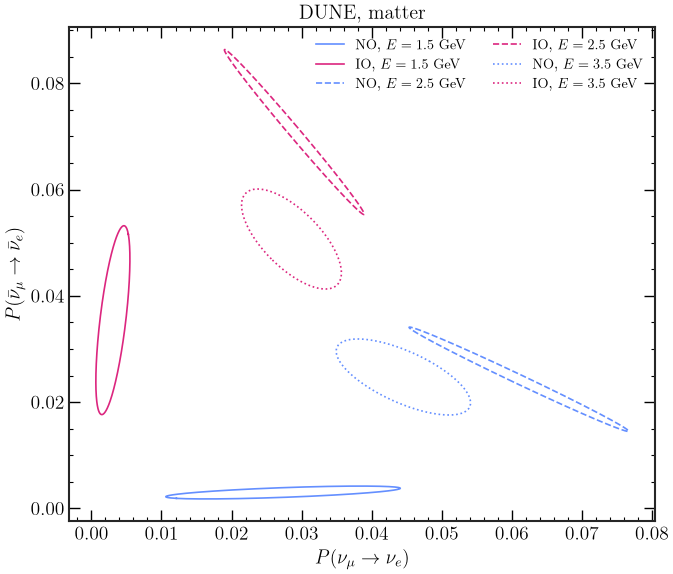

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
for k, E in enumerate([1.5, 2.5, 3.5]):
    for i, o in enumerate(ORDERINGS):
        p, pb = biprob("DUNE", o, True, E)
        ax.plot(p, pb, color=c[i], ls=["-", "--", ":"][k], label=f"{o}, $E = {E}$ GeV")
ax.set_xlabel(label("mu", "e")); ax.set_ylabel(label("mu", "e", anti=True))
ax.set_title("DUNE, matter")
ax.legend(fontsize="small", ncol=2)
plt.tight_layout()
plt.show()

## 5. Bi-event plots with simulated events

The experiments measure **events**, not probabilities. `far_detector_spectra/` contains, for each
experiment, the selected far-detector events per energy bin for $P=1$ (flux × cross section ×
efficiency × exposure; see `far_detector_spectra/README.md`), and `predict()` multiplies them by the
probabilities. Here: total $e$-like events (signal + backgrounds) in the neutrino vs antineutrino beam,
for matter (solid) and vacuum (dashed); error bars: statistical $\sqrt N$ at $\delta_{CP}=0$.

Hyper-K has the same probabilities as T2K but ~60 times more events: the ellipses are the same shape,
the error bars are much smaller relative to them.

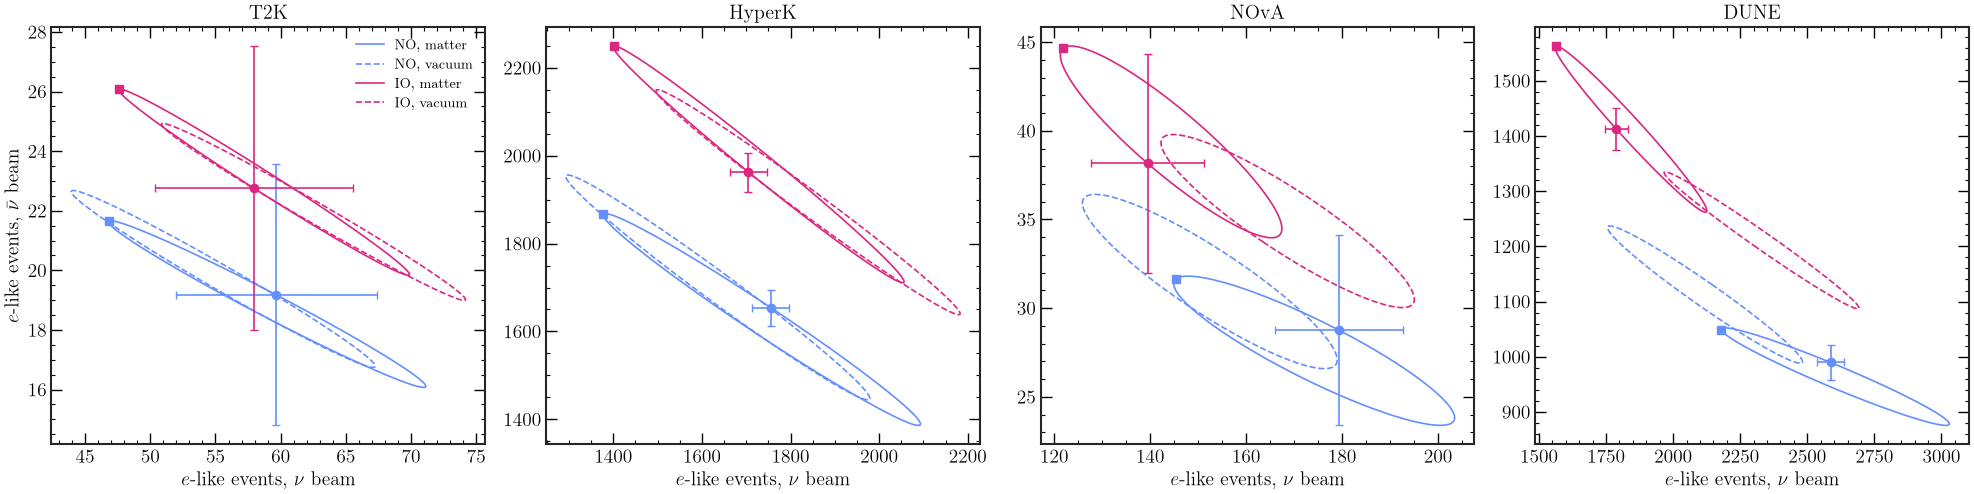

In [ ]:
deltas_ev = np.linspace(0, 360, 73)

fig, axes = plt.subplots(1, 4, figsize=(20, 5.2))
for ax, name in zip(axes, EXPERIMENTS):
    spec = load_fd_spectra(name)
    for i, o in enumerate(ORDERINGS):
        for matter, ls in [(True, "-"), (False, "--")]:
            N = np.array([[predict(name, NeutrinoOscillator(o, delta_cp=d), matter=matter, spectra=spec)[m]["e_like"].sum()
                           for m in ("FHC", "RHC")] for d in deltas_ev])
            ax.plot(N[:, 0], N[:, 1], color=c[i], ls=ls, label=f"{o}, {'matter' if matter else 'vacuum'}")
            if matter:
                ax.errorbar(N[0, 0], N[0, 1], xerr=np.sqrt(N[0, 0]), yerr=np.sqrt(N[0, 1]),
                            fmt="o", color=c[i], capsize=3)
                ax.plot(N[18, 0], N[18, 1], "s", color=c[i])
    ax.set_xlabel(r"$e$-like events, $\nu$ beam")
    ax.set_title(name)
axes[0].set_ylabel(r"$e$-like events, $\bar\nu$ beam")
axes[0].legend(fontsize="small")
plt.tight_layout()
plt.show()

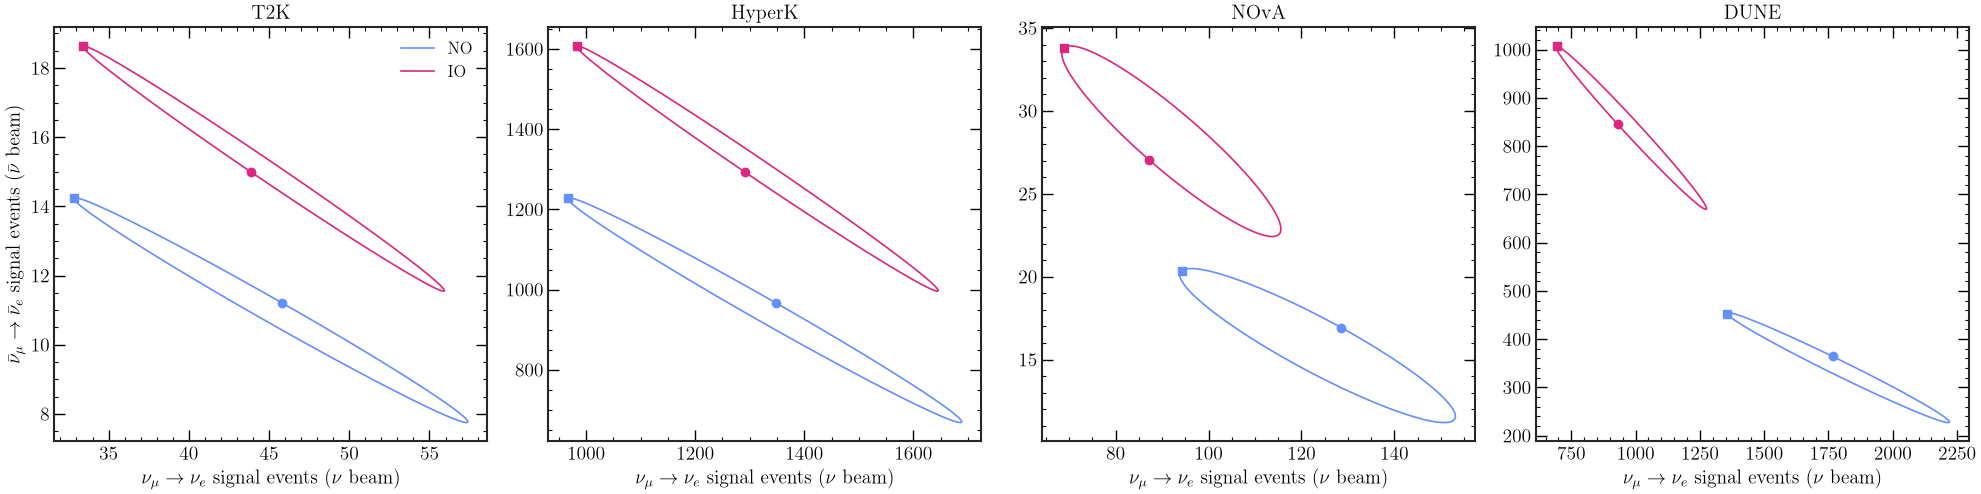

In [ ]:
# the same, with the signal only (no backgrounds): closer to the bi-probability plot
fig, axes = plt.subplots(1, 4, figsize=(20, 5.2))
for ax, name in zip(axes, EXPERIMENTS):
    spec = load_fd_spectra(name)
    for i, o in enumerate(ORDERINGS):
        N = []
        for d in deltas_ev:
            p = predict(name, NeutrinoOscillator(o, delta_cp=d), spectra=spec)
            N.append([p["FHC"]["numu_e"].sum(), p["RHC"]["numubar_e"].sum()])
        N = np.array(N)
        ax.plot(N[:, 0], N[:, 1], color=c[i], label=o)
        ax.plot(N[0, 0], N[0, 1], "o", color=c[i]); ax.plot(N[18, 0], N[18, 1], "s", color=c[i])
    ax.set_xlabel(r"$\nu_\mu\to\nu_e$ signal events ($\nu$ beam)")
    ax.set_title(name)
axes[0].set_ylabel(r"$\bar\nu_\mu\to\bar\nu_e$ signal events ($\bar\nu$ beam)")
axes[0].legend()
plt.tight_layout()
plt.show()

### 5a. How far apart are the orderings?

A simple *counting* estimate: the distance between the NO ellipse and the IO predictions in units of
the statistical error. For each true $\delta_{CP}$ (NO) we take the closest IO prediction, scanning the IO
$\delta_{CP}$ **and** $\sin^2\theta_{23}$ (otherwise the different NuFIT $\theta_{23}$ of the two orderings would
fake a separation), with
$\Delta\chi^2 = \sum_{\text{beams}} (N_\mathrm{NO}-N_\mathrm{IO})^2/N_\mathrm{NO}$.
Statistics only, two numbers per experiment and all other parameters fixed: much simpler than a real
analysis (which uses the energy spectra, the $\mu$-like samples and systematics).

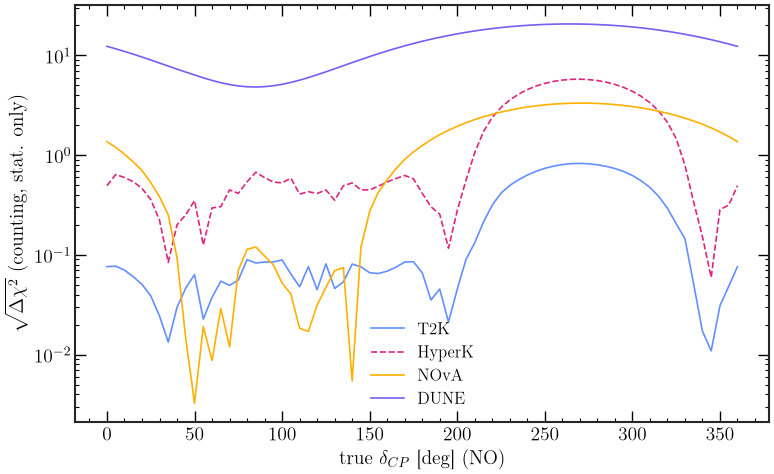

In [ ]:
s23_grid = np.linspace(0.42, 0.60, 10)
fig, ax = plt.subplots(figsize=(8, 5))
for j, name in enumerate(EXPERIMENTS):
    spec = load_fd_spectra(name)
    rate = lambda osc: [predict(name, osc, spectra=spec)[m]["e_like"].sum() for m in ("FHC", "RHC")]
    N_NO = np.array([rate(NeutrinoOscillator("NO", delta_cp=d)) for d in deltas_ev])
    N_IO = np.array([rate(NeutrinoOscillator("IO", delta_cp=d, s2_23=s)) for d in deltas_ev for s in s23_grid])
    chi2 = [np.min(np.sum((n - N_IO) ** 2 / n, axis=1)) for n in N_NO]
    ax.plot(deltas_ev, np.sqrt(chi2), color=c[j], ls="--" if name == "HyperK" else "-", label=name)
ax.set_xlabel(r"true $\delta_{CP}$ [deg] (NO)")
ax.set_ylabel(r"$\sqrt{\Delta\chi^2}$ (counting, stat. only)")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.show()

## 6. At fixed energy, $\delta_{CP}$ shows up as a different number of counts

An experiment does not measure $\delta_{CP}$ directly: it **counts events**. Fix the energy, i.e. take a window
around the peak energy ($\pm 20\%$): changing $\delta_{CP}$ changes $P(\nu_\mu\to\nu_e)$ there, hence the expected
number of $e$-like events. The band is the statistical fluctuation $\pm\sqrt N$ of a measurement.

* the counts oscillate with $\delta_{CP}$, roughly like $a + b\sin\delta_{CP} + c\cos\delta_{CP}$ (mostly $\sin\delta_{CP}$);
* a *measured* number of counts (dotted line, here the NO prediction for the NuFIT value $\delta_{CP}=212^\circ$) is
  compatible with **two** values of $\delta_{CP}$, close to $\delta$ and $180^\circ-\delta$: one number cannot fix one angle;
* for T2K/NOvA the band is wide: with few events even the orderings overlap.

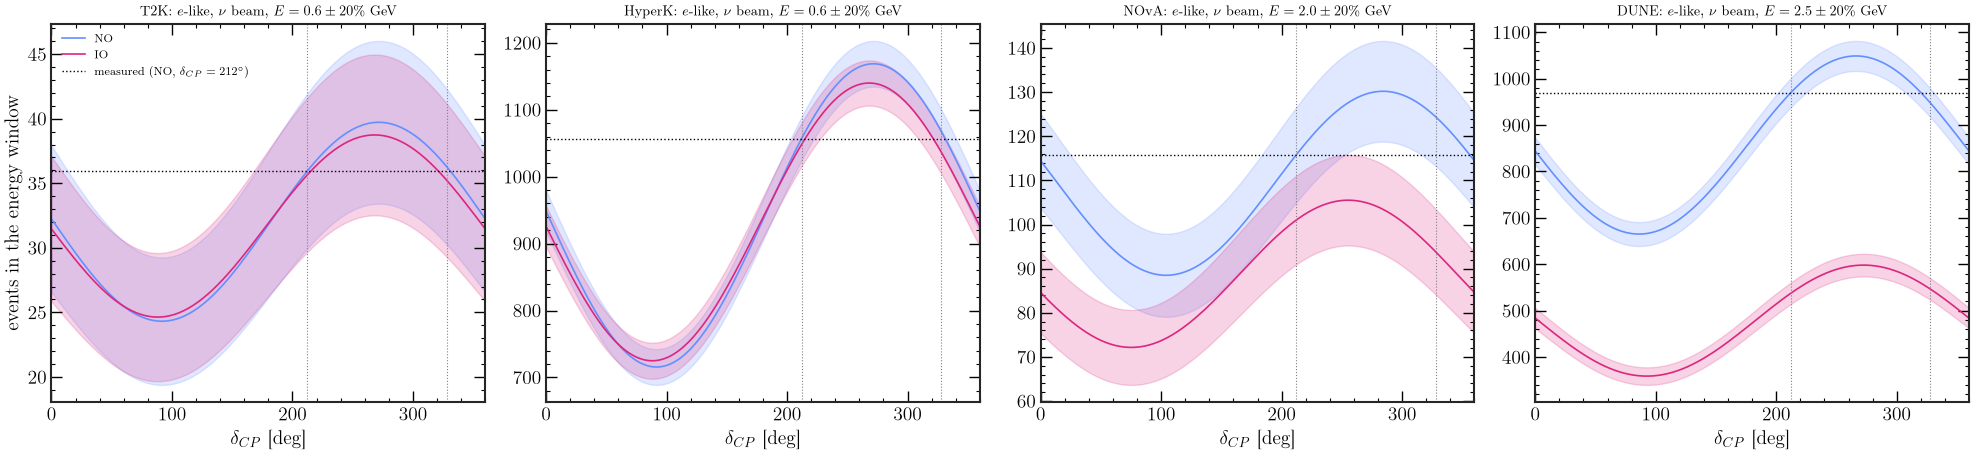

In [ ]:
def window_counts(name, osc, E0, mode="FHC", sample="e_like", spec=None, width=0.2):
    # expected events with E in [E0 (1 - width), E0 (1 + width)]
    p = predict(name, osc, spectra=spec)
    E = p["E"]
    m = (E >= E0 * (1 - width)) & (E <= E0 * (1 + width))
    return p[mode][sample][m].sum()

TRUE_DELTA = 212          # "measured" value (NuFIT 6.0 NO)
dgrid = np.linspace(0, 360, 181)
fig, axes = plt.subplots(1, 4, figsize=(20, 4.8))
for ax, name in zip(axes, EXPERIMENTS):
    spec = load_fd_spectra(name)
    E0 = get_experiment(name)["E_peak"]
    for i, o in enumerate(ORDERINGS):
        N = np.array([window_counts(name, NeutrinoOscillator(o, delta_cp=d), E0, spec=spec) for d in dgrid])
        ax.plot(dgrid, N, color=c[i], label=o)
        ax.fill_between(dgrid, N - np.sqrt(N), N + np.sqrt(N), color=c[i], alpha=0.2)
    n_obs = window_counts(name, NeutrinoOscillator("NO", delta_cp=TRUE_DELTA), E0, spec=spec)
    ax.axhline(n_obs, color="k", ls=":", lw=1, label=rf"measured (NO, $\delta_{{CP}}={TRUE_DELTA}^\circ$)")
    ax.axvline(TRUE_DELTA, color="grey", ls=":", lw=0.8); ax.axvline(360 + 180 - TRUE_DELTA, color="grey", ls=":", lw=0.8)
    ax.set_title(rf"{name}: $e$-like, $\nu$ beam, $E = {E0}\pm20\%$ GeV", fontsize="small")
    ax.set_xlabel(r"$\delta_{CP}$ [deg]")
    ax.set_xlim(0, 360)
axes[0].set_ylabel("events in the energy window")
axes[0].legend(fontsize="x-small")
plt.tight_layout()
plt.show()

The same thing bin by bin: the whole $e$-like spectrum moves up and down with $\delta_{CP}$
(DUNE, neutrino beam, NO).

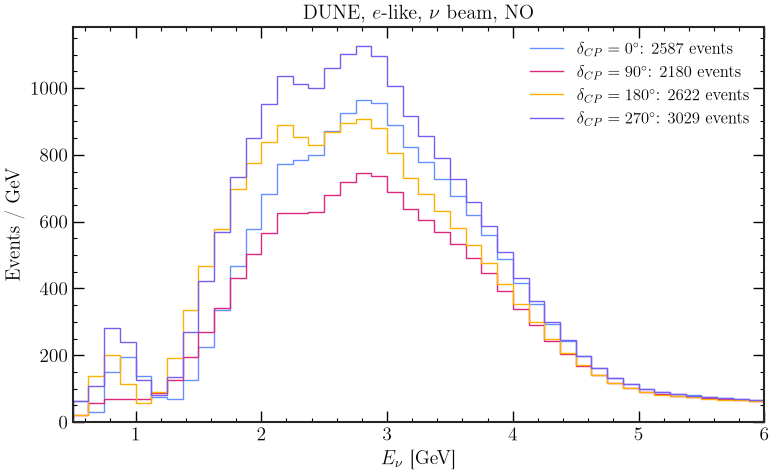

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
spec = load_fd_spectra("DUNE")
for i, d in enumerate([0, 90, 180, 270]):
    p = predict("DUNE", NeutrinoOscillator("NO", delta_cp=d), spectra=spec)
    w = np.diff(p["edges"])
    ax.stairs(p["FHC"]["e_like"] / w, p["edges"], color=c[i],
              label=rf"$\delta_{{CP}}={d}^\circ$: {p['FHC']['e_like'].sum():.0f} events")
ax.set_xlim(0.5, 6)
ax.set_xlabel(r"$E_\nu$ [GeV]"); ax.set_ylabel("Events / GeV")
ax.set_title(r"DUNE, $e$-like, $\nu$ beam, NO")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Absolute vs relative measurement: why we need antineutrinos

The goal is $\delta_{CP}$. With **neutrinos only** we must use the *absolute* number of events, which has two problems:

1. **degeneracy:** as seen above, one number of counts corresponds to two values of $\delta_{CP}$
   (e.g. $\delta$ and $180^\circ-\delta$ give almost the same rate, since the rate depends mainly on $\sin\delta_{CP}$);
2. **normalisation:** the predicted rate depends on the flux, the cross section and the efficiency, known only to
   a few percent. A 5% change of the normalisation moves the prediction as much as a large change of $\delta_{CP}$.

With **neutrinos and antineutrinos** the CP-odd term changes sign ($\sin\delta_{CP}\to-\sin\delta_{CP}$): if
$\delta_{CP}=270^\circ$, the $\nu$ rate goes *up* and the $\bar\nu$ rate goes *down*, while a normalisation
error moves both in the *same* direction. The *relative* comparison of $\nu$ and $\bar\nu$ separates the two effects.

### 7a. The CP asymmetry

At the level of probabilities, the natural relative quantity is
$$A_{CP} = \frac{P(\nu_\mu\to\nu_e) - P(\bar\nu_\mu\to\bar\nu_e)}{P(\nu_\mu\to\nu_e) + P(\bar\nu_\mu\to\bar\nu_e)},$$
where any factor common to $\nu$ and $\bar\nu$ cancels in the ratio. In vacuum $A_{CP}\propto\sin\delta_{CP}$ (zero for
$\delta_{CP}=0,180^\circ$); in matter there is an extra, $\delta_{CP}$-independent, *fake* asymmetry that grows with the
baseline and has opposite sign for NO and IO.

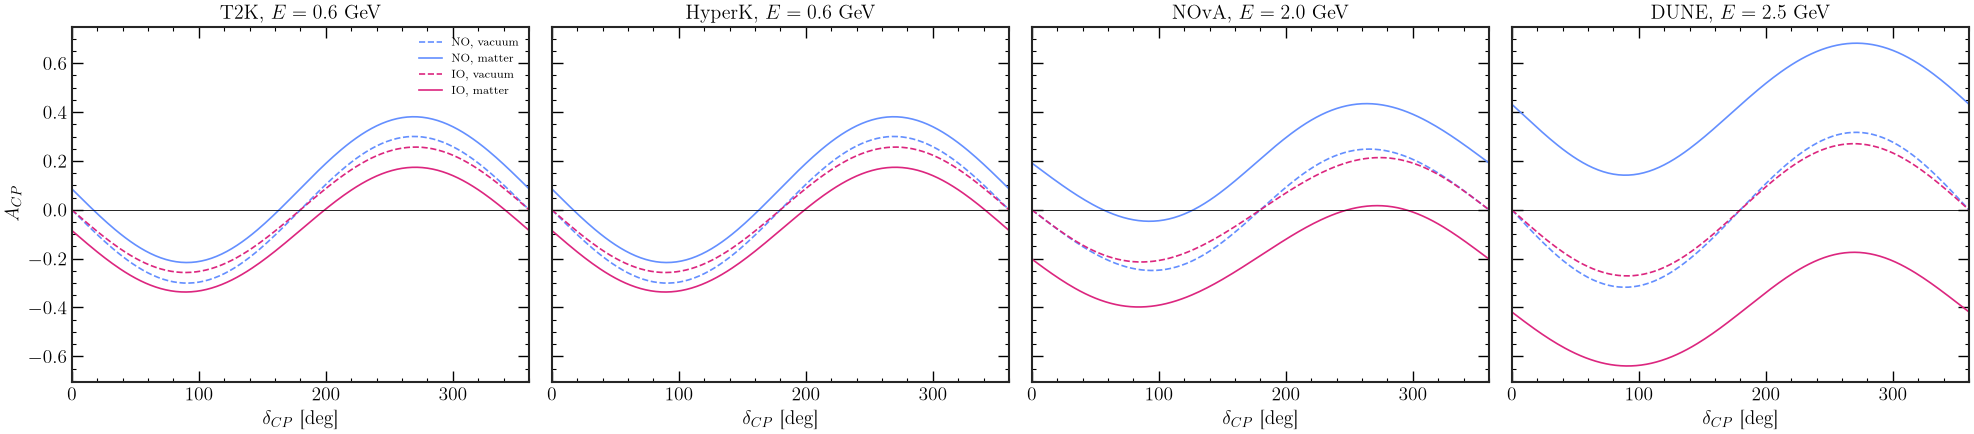

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.6), sharey=True)
for ax, name in zip(axes, EXPERIMENTS):
    E0 = get_experiment(name)["E_peak"]
    for i, o in enumerate(ORDERINGS):
        for matter, ls in [(False, "--"), (True, "-")]:
            A = []
            for d in dgrid:
                nu = NeutrinoOscillator.from_experiment(name, ordering=o, delta_cp=d)
                nub = NeutrinoOscillator.from_experiment(name, ordering=o, delta_cp=d, antineutrino=True)
                p, pb = nu.probability("mu", "e", E=E0, matter=matter), nub.probability("mu", "e", E=E0, matter=matter)
                A.append((p - pb) / (p + pb))
            ax.plot(dgrid, A, color=c[i], ls=ls, label=f"{o}, {'matter' if matter else 'vacuum'}")
    ax.axhline(0, color="k", lw=0.6)
    ax.set_title(f"{name}, $E = {E0}$ GeV")
    ax.set_xlabel(r"$\delta_{CP}$ [deg]")
    ax.set_xlim(0, 360)
axes[0].set_ylabel(r"$A_{CP}$")
axes[0].legend(fontsize="x-small")
plt.tight_layout()
plt.show()

### 7b. A toy measurement of $\delta_{CP}$: $\nu$ only vs $\nu+\bar\nu$

Pseudo-data: the expected $e$-like events of Hyper-K and DUNE for NO and true $\delta_{CP}=212^\circ$. We fit $\delta_{CP}$ with
$$\chi^2(\delta_{CP}) = \min_{k}\left[\sum_{i}\frac{\left(N_i^\mathrm{obs} - k\,N_i^\mathrm{pred}(\delta_{CP})\right)^2}{N_i^\mathrm{obs}}
+ \left(\frac{k-1}{\sigma_k}\right)^2\right],$$
where $k$ is a **common normalisation** (flux × cross section × efficiency) with a prior uncertainty $\sigma_k=5\%$,
and $i$ runs over the numbers we use:

* **$\nu$ only, total counts** (absolute measurement): the normalisation absorbs part of the $\delta_{CP}$ effect and
  $\delta$ vs $180^\circ-\delta$ are not distinguished: wide, double minimum;
* **$\nu$ only, normalisation known exactly** ($\sigma_k\to0$): better, but still two minima;
* **$\nu+\bar\nu$, total counts** (relative measurement): a change of $k$ cannot mimic the *opposite* movement of the
  $\nu$ and $\bar\nu$ rates, so the sign of $\sin\delta_{CP}$ is fixed very strongly ($\sin\delta_{CP}>0$ is excluded);
  the $\delta\leftrightarrow180^\circ-\delta$ ambiguity (same $\sin\delta_{CP}$) remains;
* **$\nu+\bar\nu$, energy spectrum**: the $\cos\delta_{CP}$ term shifts the oscillation maximum in energy, so the
  spectrum shape resolves the last ambiguity: $\delta_{CP}$ is measured.

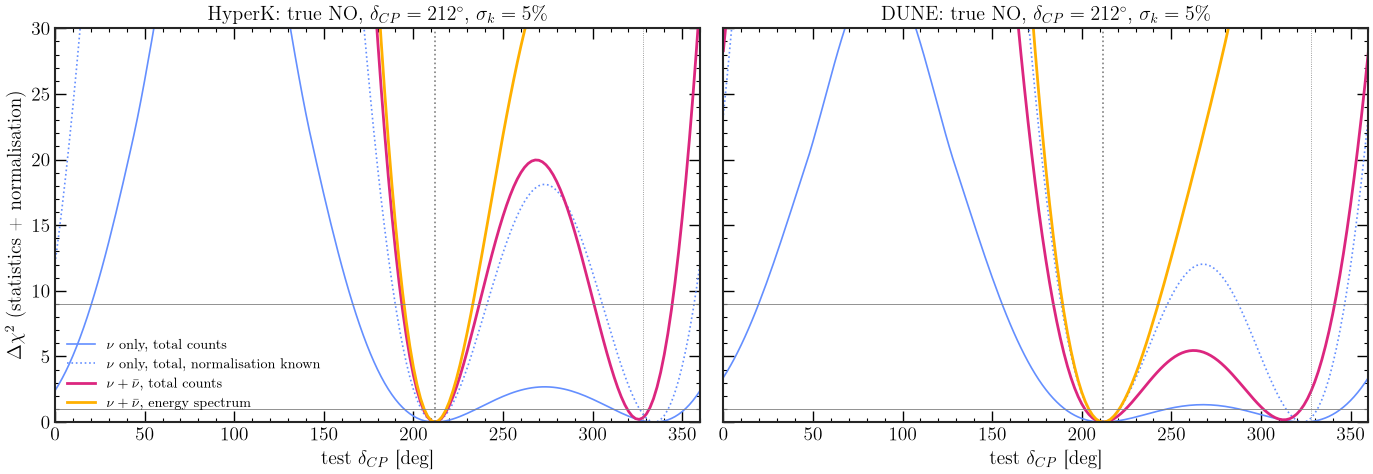

In [ ]:
k_grid = np.linspace(0.80, 1.20, 401)
SIGMA_K = 0.05
TRUE_DELTA = 212
BINS = {"HyperK": np.array([0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0, 1.25]),
        "DUNE":   np.array([0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 5, 6, 8])}

def observables(name, osc, beams, binned, spec):
    p = predict(name, osc, spectra=spec)
    out = []
    for m in beams:
        y = p[m]["e_like"]
        if binned:
            e = p["edges"]
            out += [y[(e[:-1] >= lo - 1e-9) & (e[1:] <= hi + 1e-9)].sum()
                    for lo, hi in zip(BINS[name][:-1], BINS[name][1:])]
        else:
            out.append(y.sum())
    return np.array(out)

def chi2_scan(name, beams, binned=False, sigma_k=SIGMA_K):
    spec = load_fd_spectra(name)
    n_obs = observables(name, NeutrinoOscillator("NO", delta_cp=TRUE_DELTA), beams, binned, spec)
    out = []
    for d in dgrid:
        n_pred = observables(name, NeutrinoOscillator("NO", delta_cp=d), beams, binned, spec)
        chi = (((n_obs[None, :] - k_grid[:, None] * n_pred[None, :]) ** 2 / n_obs).sum(axis=1)
               + ((k_grid - 1) / sigma_k) ** 2)
        out.append(chi.min())
    out = np.array(out)
    return out - out.min()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, name in zip(axes, ["HyperK", "DUNE"]):
    ax.plot(dgrid, chi2_scan(name, ["FHC"]), color=c[0], label=r"$\nu$ only, total counts")
    ax.plot(dgrid, chi2_scan(name, ["FHC"], sigma_k=1e-6), color=c[0], ls=":", label=r"$\nu$ only, total, normalisation known")
    ax.plot(dgrid, chi2_scan(name, ["FHC", "RHC"]), color=c[1], lw=2, label=r"$\nu+\bar\nu$, total counts")
    ax.plot(dgrid, chi2_scan(name, ["FHC", "RHC"], binned=True), color=c[2], lw=2, label=r"$\nu+\bar\nu$, energy spectrum")
    ax.axvline(TRUE_DELTA, color="grey", ls=":")
    ax.axvline(360 + 180 - TRUE_DELTA, color="grey", ls=":", lw=0.6)
    ax.axhline(1, color="grey", lw=0.6); ax.axhline(9, color="grey", lw=0.6)
    ax.set_xlabel(r"test $\delta_{CP}$ [deg]")
    ax.set_title(rf"{name}: true NO, $\delta_{{CP}}={TRUE_DELTA}^\circ$, $\sigma_k={100*SIGMA_K:.0f}\%$")
    ax.set_xlim(0, 360); ax.set_ylim(0, 30)
axes[0].set_ylabel(r"$\Delta\chi^2$ (statistics + normalisation)")
axes[0].legend(fontsize="small")
plt.tight_layout()
plt.show()

**What to take home**

* at fixed energy, $\delta_{CP}$ is a **number of counts**; one number gives an ambiguous $\delta_{CP}$
  ($\delta$ or $180^\circ-\delta$);
* a measurement with neutrinos only is an **absolute** measurement and is limited by the normalisation
  (flux, cross section, efficiency) and by the $\delta \leftrightarrow 180^\circ-\delta$ degeneracy;
* comparing neutrinos and antineutrinos is a **relative** measurement: the CP-violating term changes sign, common
  normalisation effects do not: this fixes the sign of $\sin\delta_{CP}$;
* the **energy spectrum** resolves the remaining $\delta\leftrightarrow180^\circ-\delta$ ambiguity (the $\cos\delta_{CP}$ term);
* real experiments also use near detectors to constrain the normalisation, and must separate the *fake*
  asymmetry due to matter from the genuine CP violation.

## 8. $P(\nu_e\to\nu_e)$ does not depend on $\delta_{CP}$

$\delta_{CP}$ can be rotated into the $\mu$–$\tau$ sector together with $\theta_{23}$; the matter potential only
acts on $\nu_e$ and commutes with that rotation. So $P_{ee}$ is independent of $\delta_{CP}$ in vacuum *and*
in constant-density matter.

In [ ]:
for name in EXPERIMENTS:
    osc = NeutrinoOscillator.from_experiment(name)
    Pee = []
    for d in np.linspace(0, 360, 37):
        osc.set_params(delta_cp=d)
        Pee.append([osc.vacuum("e", "e"), osc.matter("e", "e")])
    Pee = np.array(Pee)                                     # (delta, vac/mat, energy)
    spread = Pee.max(axis=0) - Pee.min(axis=0)
    print(f"{name:7s}: max spread over delta_CP  vacuum {spread[0].max():.1e}   matter {spread[1].max():.1e}")

T2K    : max spread over delta_CP  vacuum 2.2e-16   matter 0.0e+00
HyperK : max spread over delta_CP  vacuum 2.2e-16   matter 0.0e+00
NOvA   : max spread over delta_CP  vacuum 2.2e-16   matter 0.0e+00
DUNE   : max spread over delta_CP  vacuum 2.2e-16   matter 0.0e+00
